In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

ruta = "/content/drive/MyDrive/cirmenes"

for d in os.listdir(ruta):
    print(repr(d))

'base de datos '
'estado_arte_crimen_colombia.docx'
'01_pipeline_limpieza.ipynb'


In [ ]:
import os
import pandas as pd

carpeta = "/content/drive/MyDrive/cirmenes/base de datos "

archivos = os.listdir(carpeta)

print("Archivos encontrados:")
for a in archivos:
    print("-", a)

Archivos encontrados:
- 2024.xlsx
- 2023.xlsx
- 2025.xlsx
- 2026.xlsx
- 2020.xlsx
- 2022.xlsx
- 2021.xlsx
- CODDANE.xlsx


# **Fase 1. Integración y consolidación de bases de datos de criminalidad**

In [ ]:
archivo = "2020.xlsx"   # directo, sin depender del índice
ruta = os.path.join(carpeta, archivo)

df_2020 = pd.read_excel(ruta)

print("Archivo:", archivo)
print("Dimensión:", df_2020.shape)

print("\nColumnas:")
print(df_2020.columns.tolist())

print("\nPrimeras filas:")
display(df_2020.head())

Archivo: 2020.xlsx
Dimensión: (655229, 10)

Columnas:
['ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD']

Primeras filas:


,ARMAS MEDIOS,DEPARTAMENTO,MUNICIPIO,FECHA HECHO,GENERO,*AGRUPA EDAD PERSONA*,CODIGO DANE,DELITOS,MES,CANTIDAD
0,MOTO,CAUCA,Santander de Quilichao,01/01/2020,MASCULINO,ADULTOS,19698.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
1,MOTO,TOLIMA,Purificación,01/01/2020,MASCULINO,ADULTOS,73585.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
2,MOTO,HUILA,Aipe,01/01/2020,MASCULINO,ADULTOS,41016.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
3,MOTO,TOLIMA,Suárez,01/01/2020,MASCULINO,ADULTOS,73770.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
4,MOTO,ANTIOQUIA,El Santuario,01/01/2020,MASCULINO,ADULTOS,5697.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0


In [ ]:
archivo = "2021.xlsx"
ruta = os.path.join(carpeta, archivo)

df_2021 = pd.read_excel(ruta)

print("Archivo:", archivo)
print("Dimensión:", df_2021.shape)

print("\nColumnas:")
print(df_2021.columns.tolist())

print("\nPrimeras filas:")
display(df_2021.head())

Archivo: 2021.xlsx
Dimensión: (798657, 9)

Columnas:
['DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD']

Primeras filas:


,DEPARTAMENTO,MUNICIPIO,FECHA HECHO,GENERO,*AGRUPA EDAD PERSONA*,CODIGO DANE,DELITOS,MES,CANTIDAD
0,CÓRDOBA,Montería (CT),01/01/2021,MASCULINO,ADULTOS,23001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
1,NARIÑO,Mallama,01/01/2021,MASCULINO,ADULTOS,52435.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
2,META,Guamal,01/01/2021,MASCULINO,ADULTOS,50318.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
3,CÓRDOBA,San Antero,01/01/2021,MASCULINO,ADULTOS,23672.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
4,ANTIOQUIA,Girardota,01/01/2021,FEMENINO,ADOLESCENTES,5308.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0


In [ ]:
import re
import unicodedata
import pandas as pd
import numpy as np

def normalizar(col):
    col = str(col).strip().lower()
    col = ''.join(
        c for c in unicodedata.normalize('NFD', col)
        if unicodedata.category(c) != 'Mn'
    )
    col = re.sub(r"[^a-z0-9]+", "_", col)
    return col.strip("_")

# Copias para no dañar los originales
df_2020_tmp = df_2020.copy()
df_2021_tmp = df_2021.copy()

# Normalizar columnas
df_2020_tmp.columns = [normalizar(c) for c in df_2020_tmp.columns]
df_2021_tmp.columns = [normalizar(c) for c in df_2021_tmp.columns]

# Agregar año
df_2020_tmp["anio"] = 2020
df_2021_tmp["anio"] = 2021

# Unir
df_total = pd.concat([df_2020_tmp, df_2021_tmp], ignore_index=True, sort=False)

print("Dimensión de la base consolidada:", df_total.shape)
print("\nColumnas finales:")
print(df_total.columns.tolist())

print("\nRegistros por año:")
print(df_total["anio"].value_counts().sort_index())

display(df_total.head())
print("\nMuestra aleatoria de 5 registros:")
display(df_total.sample(5, random_state=42))

Dimensión de la base consolidada: (1453886, 11)

Columnas finales:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio']

Registros por año:
anio
2020    655229
2021    798657
Name: count, dtype: int64


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio
0,MOTO,CAUCA,Santander de Quilichao,01/01/2020,MASCULINO,ADULTOS,19698.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0,2020
1,MOTO,TOLIMA,Purificación,01/01/2020,MASCULINO,ADULTOS,73585.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0,2020
2,MOTO,HUILA,Aipe,01/01/2020,MASCULINO,ADULTOS,41016.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0,2020
3,MOTO,TOLIMA,Suárez,01/01/2020,MASCULINO,ADULTOS,73770.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0,2020
4,MOTO,ANTIOQUIA,El Santuario,01/01/2020,MASCULINO,ADULTOS,5697.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0,2020



Muestra aleatoria de 5 registros:


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio
669641,NaN,SANTANDER,Floridablanca,26/01/2021,MASCULINO,ADULTOS,68276.0,ARTÍCULO 120. LESIONES CULPOSAS ( EN ACCIDENTE...,1.0,1.0,2021
691091,NaN,CÓRDOBA,San Pelayo,20/11/2021,MASCULINO,ADULTOS,23686.0,ARTÍCULO 120. LESIONES CULPOSAS ( EN ACCIDENTE...,11.0,1.0,2021
1269261,NaN,SANTANDER,Piedecuesta,07/09/2021,MASCULINO,ADULTOS,68547.0,ARTÍCULO 239. HURTO RESIDENCIAS,9.0,1.0,2021
1186765,NaN,VALLE,Cali (CT),17/04/2021,MASCULINO,ADULTOS,76001.0,ARTÍCULO 239. HURTO PERSONAS,4.0,1.0,2021
1174681,NaN,VALLE,Buenaventura,19/05/2021,FEMENINO,ADULTOS,76109.0,ARTÍCULO 239. HURTO PERSONAS,5.0,1.0,2021


In [ ]:
archivo = "2023.xlsx"
ruta = os.path.join(carpeta, archivo)

df_2023 = pd.read_excel(ruta)

print("Archivo:", archivo)
print("Dimensión:", df_2023.shape)

print("\nColumnas:")
print(df_2023.columns.tolist())

print("\nPrimeras filas:")
display(df_2023.head())

Archivo: 2023.xlsx
Dimensión: (919983, 10)

Columnas:
['ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD']

Primeras filas:


,ARMAS MEDIOS,DEPARTAMENTO,MUNICIPIO,FECHA HECHO,GENERO,*AGRUPA EDAD PERSONA*,CODIGO DANE,DELITOS,MES,CANTIDAD
0,VEHICULO,VALLE,Palmira,01/01/2023,FEMENINO,ADULTOS,76520.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
1,MOTO,HUILA,San Agustín,01/01/2023,MASCULINO,ADULTOS,41668.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
2,MOTO,HUILA,San Agustín,01/01/2023,MASCULINO,ADULTOS,41668.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
3,SIN EMPLEO DE ARMAS,CESAR,Bosconia,01/01/2023,MASCULINO,ADULTOS,20060.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
4,VEHICULO,CUNDINAMARCA,Bogotá D.C. (CT),01/01/2023,MASCULINO,ADULTOS,11001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0


In [ ]:
# Copia para no alterar el original
df_2023_tmp = df_2023.copy()

# Normalizar columnas
df_2023_tmp.columns = [normalizar(c) for c in df_2023_tmp.columns]

# Agregar año
df_2023_tmp["anio"] = 2023

# Unir a la base total existente
df_total = pd.concat([df_total, df_2023_tmp], ignore_index=True, sort=False)

# Verificación
print("Dimensión actual de la base consolidada:", df_total.shape)

print("\nColumnas actuales:")
print(df_total.columns.tolist())

print("\nRegistros por año:")
print(df_total["anio"].value_counts().sort_index())

print("\nMuestra aleatoria de 5 registros:")
display(df_total.sample(5, random_state=42))

Dimensión actual de la base consolidada: (2373869, 11)

Columnas actuales:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio']

Registros por año:
anio
2020    655229
2021    798657
2023    919983
Name: count, dtype: int64

Muestra aleatoria de 5 registros:


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio
251153,CONTUNDENTES,SANTANDER,Floridablanca,04/08/2020,FEMENINO,ADULTOS,68276.0,ARTÍCULO 205. ACCESO CARNAL VIOLENTO,8.0,1.0,2020
1187608,NaN,ANTIOQUIA,Bello,24/04/2021,MASCULINO,ADULTOS,5088.0,ARTÍCULO 239. HURTO PERSONAS,4.0,1.0,2021
1900043,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Mosquera,13/09/2023,MASCULINO,ADULTOS,25473.0,ARTÍCULO 239. HURTO PERSONAS,9.0,1.0,2023
1825187,SIN EMPLEO DE ARMAS,ANTIOQUIA,Andes,04/11/2023,FEMENINO,ADULTOS,5034.0,ARTÍCULO 239. HURTO PERSONAS,11.0,1.0,2023
222727,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Bogotá D.C. (CT),18/11/2020,FEMENINO,ADULTOS,11001.0,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,11.0,1.0,2020


In [ ]:
archivo = "2022.xlsx"
ruta = os.path.join(carpeta, archivo)

df_2022 = pd.read_excel(ruta)

print("Archivo:", archivo)
print("Dimensión:", df_2022.shape)

print("\nColumnas:")
print(df_2022.columns.tolist())

print("\nPrimeras filas:")
display(df_2022.head())

Archivo: 2022.xlsx
Dimensión: (866671, 10)

Columnas:
['ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD']

Primeras filas:


,ARMAS MEDIOS,DEPARTAMENTO,MUNICIPIO,FECHA HECHO,GENERO,*AGRUPA EDAD PERSONA*,CODIGO DANE,DELITOS,MES,CANTIDAD
0,MOTO,CÓRDOBA,San Pelayo,01/01/2022,MASCULINO,ADULTOS,23686.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
1,VEHICULO,NARIÑO,Aldana,01/01/2022,FEMENINO,ADULTOS,52022.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
2,MOTO,SUCRE,Sincelejo (CT),01/01/2022,MASCULINO,ADULTOS,70001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
3,MOTO,CÓRDOBA,Montería (CT),01/01/2022,MASCULINO,ADULTOS,23001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
4,MOTO,MAGDALENA,Guamal,01/01/2022,MASCULINO,ADULTOS,47318.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0


In [ ]:
# Copia para no alterar el original
df_2022_tmp = df_2022.copy()

# Normalizar columnas
df_2022_tmp.columns = [normalizar(c) for c in df_2022_tmp.columns]

# Agregar año
df_2022_tmp["anio"] = 2022

# Unir a la base total existente
df_total = pd.concat([df_total, df_2022_tmp], ignore_index=True, sort=False)

# Verificación
print("Dimensión actual de la base consolidada:", df_total.shape)

print("\nColumnas actuales:")
print(df_total.columns.tolist())

print("\nRegistros por año:")
print(df_total["anio"].value_counts().sort_index())

print("\nMuestra aleatoria de 5 registros:")
display(df_total.sample(5, random_state=42))

Dimensión actual de la base consolidada: (3240540, 11)

Columnas actuales:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio']

Registros por año:
anio
2020    655229
2021    798657
2022    866671
2023    919983
Name: count, dtype: int64

Muestra aleatoria de 5 registros:


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio
2958924,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Bogotá D.C. (CT),30/03/2022,MASCULINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,3.0,1.0,2022
1144923,NaN,CUNDINAMARCA,Bogotá D.C. (CT),20/06/2021,FEMENINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,6.0,1.0,2021
411728,ARMA DE FUEGO,CUNDINAMARCA,Bogotá D.C. (CT),13/05/2020,FEMENINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,5.0,1.0,2020
1552418,ARMA DE FUEGO,TOLIMA,Chaparral,18/06/2023,MASCULINO,ADOLESCENTES,73168.0,ARTÍCULO 111. LESIONES PERSONALES,6.0,1.0,2023
212312,CONTUNDENTES,BOYACÁ,Duitama,06/08/2020,FEMENINO,ADULTOS,15238.0,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,8.0,1.0,2020


In [ ]:
archivo = "2024.xlsx"
ruta = os.path.join(carpeta, archivo)

df_2024 = pd.read_excel(ruta)

print("Archivo:", archivo)
print("Dimensión:", df_2024.shape)

print("\nColumnas:")
print(df_2024.columns.tolist())

print("\nPrimeras filas:")
display(df_2024.head())

Archivo: 2024.xlsx
Dimensión: (834156, 10)

Columnas:
['ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD']

Primeras filas:


,ARMAS MEDIOS,DEPARTAMENTO,MUNICIPIO,FECHA HECHO,GENERO,*AGRUPA EDAD PERSONA*,CODIGO DANE,DELITOS,MES,CANTIDAD
0,NO REPORTADO,ANTIOQUIA,Medellín (CT),01/01/2024,MASCULINO,ADULTOS,5001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
1,NO REPORTADO,ANTIOQUIA,Medellín (CT),01/01/2024,FEMENINO,ADULTOS,5001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
2,MOTO,ANTIOQUIA,Valdivia,01/01/2024,MASCULINO,ADULTOS,5854.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
3,VEHICULO,MAGDALENA,Zona Bananera,01/01/2024,MASCULINO,ADOLESCENTES,47980.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
4,MOTO,ANTIOQUIA,Amalfi,01/01/2024,FEMENINO,ADOLESCENTES,5031.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0


In [ ]:
# Copia para no alterar el original
df_2024_tmp = df_2024.copy()

# Normalizar columnas
df_2024_tmp.columns = [normalizar(c) for c in df_2024_tmp.columns]

# Agregar año
df_2024_tmp["anio"] = 2024

# Unir a la base total existente
df_total = pd.concat([df_total, df_2024_tmp], ignore_index=True, sort=False)

# Verificación
print("Dimensión actual de la base consolidada:", df_total.shape)

print("\nColumnas actuales:")
print(df_total.columns.tolist())

print("\nRegistros por año:")
print(df_total["anio"].value_counts().sort_index())

print("\nMuestra aleatoria de 5 registros:")
display(df_total.sample(5, random_state=42))

Dimensión actual de la base consolidada: (4074696, 11)

Columnas actuales:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio']

Registros por año:
anio
2020    655229
2021    798657
2022    866671
2023    919983
2024    834156
Name: count, dtype: int64

Muestra aleatoria de 5 registros:


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio
2533889,CONTUNDENTES,ATLÁNTICO,Barranquilla (CT),31/01/2022,FEMENINO,ADULTOS,8001.0,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,1.0,1.0,2022
852257,NaN,ANTIOQUIA,Itagui,15/06/2021,FEMENINO,ADULTOS,5360.0,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,6.0,1.0,2021
2740822,ARMA BLANCA / CORTOPUNZANTE,CUNDINAMARCA,Bogotá D.C. (CT),26/10/2022,MASCULINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,10.0,1.0,2022
1782590,SIN EMPLEO DE ARMAS,ANTIOQUIA,Apartadó,26/12/2023,FEMENINO,ADULTOS,5045.0,ARTÍCULO 239. HURTO PERSONAS,12.0,1.0,2023
563776,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Bogotá D.C. (CT),17/01/2020,NaN,ADULTOS,11001.0,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,1.0,1.0,2020


In [ ]:
archivo = "2025.xlsx"
ruta = os.path.join(carpeta, archivo)

df_2025 = pd.read_excel(ruta)

print("Archivo:", archivo)
print("Dimensión:", df_2025.shape)

print("\nColumnas:")
print(df_2025.columns.tolist())

print("\nPrimeras filas:")
display(df_2025.head())

Archivo: 2025.xlsx
Dimensión: (780240, 10)

Columnas:
['ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD']

Primeras filas:


,ARMAS MEDIOS,DEPARTAMENTO,MUNICIPIO,FECHA HECHO,GENERO,*AGRUPA EDAD PERSONA*,CODIGO DANE,DELITOS,MES,CANTIDAD
0,VEHICULO,CUNDINAMARCA,Bogotá D.C. (CT),01/01/2025,MASCULINO,ADULTOS,11001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
1,VEHICULO,NARIÑO,San Andres de Tumaco,01/01/2025,MASCULINO,ADULTOS,52835.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
2,VEHICULO,NARIÑO,San Andres de Tumaco,01/01/2025,MASCULINO,ADULTOS,52835.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
3,MOTO,ANTIOQUIA,Barbosa,01/01/2025,MASCULINO,ADULTOS,5079.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
4,VEHICULO,CUNDINAMARCA,Bogotá D.C. (CT),01/01/2025,MASCULINO,ADULTOS,11001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0


In [ ]:
# Copia para no alterar el original
df_2025_tmp = df_2025.copy()

# Normalizar columnas
df_2025_tmp.columns = [normalizar(c) for c in df_2025_tmp.columns]

# Agregar año
df_2025_tmp["anio"] = 2025

# Unir a la base total existente
df_total = pd.concat([df_total, df_2025_tmp], ignore_index=True, sort=False)

# Verificación
print("Dimensión actual de la base consolidada:", df_total.shape)

print("\nColumnas actuales:")
print(df_total.columns.tolist())

print("\nRegistros por año:")
print(df_total["anio"].value_counts().sort_index())

print("\nMuestra aleatoria de 5 registros:")
display(df_total.sample(5, random_state=42))

Dimensión actual de la base consolidada: (4854936, 11)

Columnas actuales:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio']

Registros por año:
anio
2020    655229
2021    798657
2022    866671
2023    919983
2024    834156
2025    780240
Name: count, dtype: int64

Muestra aleatoria de 5 registros:


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio
421825,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Soacha,04/04/2020,MASCULINO,ADULTOS,25754.0,ARTÍCULO 239. HURTO PERSONAS,4.0,1.0,2020
1982604,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Bogotá D.C. (CT),27/06/2023,FEMENINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,6.0,1.0,2023
1880053,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Bogotá D.C. (CT),26/09/2023,MASCULINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,9.0,1.0,2023
2096728,ARMA DE FUEGO,CUNDINAMARCA,Bogotá D.C. (CT),01/03/2023,MASCULINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,3.0,1.0,2023
2821399,CONTUNDENTES,CUNDINAMARCA,Bogotá D.C. (CT),31/08/2022,MASCULINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO PERSONAS,8.0,1.0,2022


In [ ]:
archivo = "2026.xlsx"
ruta = os.path.join(carpeta, archivo)

df_2026 = pd.read_excel(ruta)

print("Archivo:", archivo)
print("Dimensión:", df_2026.shape)

print("\nColumnas:")
print(df_2026.columns.tolist())

print("\nPrimeras filas:")
display(df_2026.head())

Archivo: 2026.xlsx
Dimensión: (58821, 10)

Columnas:
['ARMAS MEDIOS', 'DEPARTAMENTO', 'MUNICIPIO', 'FECHA HECHO', 'GENERO', '*AGRUPA EDAD PERSONA*', 'CODIGO DANE', 'DELITOS', 'MES', 'CANTIDAD']

Primeras filas:


,ARMAS MEDIOS,DEPARTAMENTO,MUNICIPIO,FECHA HECHO,GENERO,*AGRUPA EDAD PERSONA*,CODIGO DANE,DELITOS,MES,CANTIDAD
0,NO REPORTADO,HUILA,Neiva (CT),01/01/2026,FEMENINO,ADULTOS,41001.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
1,MOTO,SUCRE,San Onofre,01/01/2026,MASCULINO,ADULTOS,70713.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
2,VEHICULO,MAGDALENA,Fundación,01/01/2026,MASCULINO,ADULTOS,47288.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
3,VEHICULO,VALLE,Guadalajara de Buga,01/01/2026,MASCULINO,ADULTOS,76111.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0
4,VEHICULO,VALLE,Guadalajara de Buga,01/01/2026,MASCULINO,ADULTOS,76111.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0


In [ ]:
# Copia para no alterar el original
df_2026_tmp = df_2026.copy()

# Normalizar columnas
df_2026_tmp.columns = [normalizar(c) for c in df_2026_tmp.columns]

# Agregar año
df_2026_tmp["anio"] = 2026

# Unir a la base total existente
df_total = pd.concat([df_total, df_2026_tmp], ignore_index=True, sort=False)

# Verificación final
print("Dimensión final de la base consolidada:", df_total.shape)

print("\nColumnas finales:")
print(df_total.columns.tolist())

print("\nRegistros por año:")
print(df_total["anio"].value_counts().sort_index())

print("\nMuestra aleatoria de 5 registros:")
display(df_total.sample(5, random_state=42))

Dimensión final de la base consolidada: (4913757, 11)

Columnas finales:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio']

Registros por año:
anio
2020    655229
2021    798657
2022    866671
2023    919983
2024    834156
2025    780240
2026     58821
Name: count, dtype: int64

Muestra aleatoria de 5 registros:


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio
636450,SIN EMPLEO DE ARMAS,ANTIOQUIA,Segovia,13/12/2020,FEMENINO,ADULTOS,5736.0,ARTÍCULO 239. HURTO MOTOCICLETAS,12.0,1.0,2020
3335247,CONTUNDENTES,CUNDINAMARCA,Bogotá D.C. (CT),24/06/2024,FEMENINO,ADULTOS,11001.0,ARTÍCULO 111. LESIONES PERSONALES,6.0,1.0,2024
3034861,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Bogotá D.C. (CT),18/11/2022,MASCULINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO RESIDENCIAS,11.0,1.0,2022
2694348,ARMA BLANCA / CORTOPUNZANTE,RISARALDA,Santa Rosa de Cabal,28/12/2022,FEMENINO,ADULTOS,66682.0,ARTÍCULO 239. HURTO PERSONAS,12.0,1.0,2022
3164087,SIN EMPLEO DE ARMAS,META,Villavicencio (CT),16/06/2022,MASCULINO,ADULTOS,50001.0,ARTÍCULO 347. AMENAZAS,6.0,1.0,2022


In [ ]:
print("=== REPORTE GENERAL DE LA BASE ===")

# Dimensión
print("\nDimensión (filas, columnas):")
print(df_total.shape)

# Columnas
print("\nNúmero de variables:", len(df_total.columns))
print("\nVariables:")
for c in df_total.columns:
    print("-", c)

# Años
print("\nAños presentes:")
print(sorted(df_total["anio"].unique()))

# Registros por año
print("\nRegistros por año:")
print(df_total["anio"].value_counts().sort_index())

# Tipos de datos
print("\nTipos de datos:")
print(df_total.dtypes)

# Nulos
print("\nPorcentaje de valores nulos (%):")
display((df_total.isnull().mean()*100).round(2).sort_values(ascending=False))

# Duplicados
print("\nNúmero de registros duplicados:")
print(df_total.duplicated().sum())

=== REPORTE GENERAL DE LA BASE ===

Dimensión (filas, columnas):
(4913757, 11)

Número de variables: 11

Variables:
- armas_medios
- departamento
- municipio
- fecha_hecho
- genero
- agrupa_edad_persona
- codigo_dane
- delitos
- mes
- cantidad
- anio

Años presentes:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Registros por año:
anio
2020    655229
2021    798657
2022    866671
2023    919983
2024    834156
2025    780240
2026     58821
Name: count, dtype: int64

Tipos de datos:
armas_medios            object
departamento            object
municipio               object
fecha_hecho             object
genero                  object
agrupa_edad_persona     object
codigo_dane            float64
delitos                 object
mes                    float64
cantidad               float64
anio                     int64
dtype: object

Porcentaje de valores nulos (%):


,0
armas_medios,16.25
genero,5.20
agrupa_edad_persona,0.36
municipio,0.00
departamento,0.00
fecha_hecho,0.00
codigo_dane,0.00
delitos,0.00
mes,0.00
cantidad,0.00



Número de registros duplicados:
2601825


### Descripción técnica del proceso

En esta fase se realizó la integración de múltiples archivos en formato Excel correspondientes a registros de criminalidad en Colombia para los años 2020 a 2026. El objetivo fue construir una base de datos unificada que permitiera el análisis posterior de la información.

**Librerías utilizadas**

Se emplearon las siguientes bibliotecas de Python:

- pandas: para la manipulación y análisis de datos  
- numpy: para el manejo de valores nulos y estructuras numéricas  
- os: para la gestión de rutas y archivos en el sistema  
- re: para la limpieza y estandarización de texto  
- unicodedata: para la normalización de caracteres (eliminación de tildes)  

**Carga de datos**

Los archivos fueron cargados directamente desde Google Drive mediante la librería pandas, utilizando la función:

`pd.read_excel()`

Cada archivo fue procesado de manera individual con el fin de inspeccionar su estructura, identificar las variables disponibles y detectar posibles inconsistencias entre años.

**Estandarización de variables**

Se aplicó un proceso de normalización de nombres de columnas que incluyó:

- Conversión a minúsculas  
- Eliminación de tildes  
- Reemplazo de caracteres especiales por guiones bajos (_)  
- Eliminación de espacios en blanco  

Esto permitió garantizar consistencia en la estructura de los datos al momento de su integración.

**Incorporación de variable temporal**

A cada conjunto de datos se le agregó la variable:

`anio`

la cual identifica el año de origen de cada registro. Esta variable fue asignada manualmente durante el proceso de carga de cada archivo.

**Integración de los datos**

La consolidación de los archivos se realizó mediante la función:

`pd.concat()`

Este procedimiento permitió unir los diferentes DataFrames en una única estructura, conservando todas las variables disponibles. En los casos donde una variable no estaba presente en algún año (por ejemplo, *armas_medios* en 2021), se mantuvieron valores nulos (NaN), garantizando la integridad del conjunto de datos.

**Resultado de la fase**

Como resultado de este proceso se obtuvo una base de datos consolidada con:

- Registros correspondientes a los años 2020–2026  
- Estructura homogénea de variables  
- Inclusión de información geográfica, temporal y categórica del delito  

**Consideraciones técnicas**

Se identificaron diferencias estructurales entre algunos archivos, particularmente en la presencia de la variable *armas_medios*. Asimismo, se detectaron registros duplicados exactos, los cuales serán tratados en fases posteriores de limpieza de datos. La base consolidada mantiene el nivel de detalle original de los datos (registro por evento).

**Resumen interpretativo fase 1**

La base de datos consolidada presenta una **escala masiva**, con 6.700.411 registros y 11 variables, lo que la convierte en una fuente robusta para análisis de criminalidad en Colombia a nivel temporal, geográfico y categórico. La estructura es consistente, integrando información de siete años (2020–2026), lo que permite análisis longitudinales, aunque con una distribución desigual de registros entre años.

Se observa un **crecimiento significativo en el volumen de datos entre 2020 y 2023**, alcanzando su punto máximo en 2023 (1.839.966 registros), lo que puede indicar mayor cobertura, cambios en los sistemas de registro o incremento real de eventos. A partir de 2024 se evidencia una disminución, y el año 2026 presenta un número muy bajo de registros, lo cual sugiere que corresponde a un corte parcial y no a un año completo.

Desde el punto de vista estructural, la mayoría de las variables son de tipo categórico (object), lo que implica la necesidad de procesos de codificación o transformación si se desea aplicar modelos estadísticos o de aprendizaje automático. Variables clave como *fecha_hecho* aún están en formato texto, lo que requiere conversión a tipo fecha para análisis temporal más precisos.

En términos de calidad de datos, se identifican **niveles bajos de valores nulos en la mayoría de variables**, lo cual es positivo. Sin embargo, la variable *armas_medios* presenta un 11.92% de datos faltantes, y *genero* un 5.22%, lo que podría sesgar análisis específicos si no se tratan adecuadamente.

El hallazgo más crítico es la presencia de **4.388.479 registros duplicados**, lo que representa aproximadamente el 65% del total de la base. Esto indica un problema serio de redundancia que puede afectar cualquier análisis descriptivo o inferencial, inflando frecuencias y distorsionando patrones. Es fundamental abordar este aspecto en la siguiente fase mediante criterios claros de deduplicación (por ejemplo, combinación de variables clave como fecha, ubicación y tipo de delito).

En conjunto, la base tiene un alto potencial analítico, pero requiere una fase rigurosa de limpieza y transformación, especialmente en la eliminación de duplicados, tratamiento de valores nulos y adecuación de tipos de datos, antes de proceder a análisis más avanzados.

# ** Fase 2. Limpieza y preparación de datos **





In [ ]:
 print("Creando identificador único de evento...")

df_clean = df_total.copy()

# Crear ID de evento
df_clean["id_evento"] = (
    df_clean["fecha_hecho"].astype(str) + "_" +
    df_clean["departamento"].astype(str) + "_" +
    df_clean["municipio"].astype(str) + "_" +
    df_clean["delitos"].astype(str) + "_" +
    df_clean["genero"].astype(str) + "_" +
    df_clean["codigo_dane"].astype(str)
)

print("ID creado correctamente")

# Ver cuántos IDs únicos hay
print("\nTotal registros:", len(df_clean))
print("Eventos únicos:", df_clean["id_evento"].nunique())

print("\nEjemplo:")
display(df_clean[["id_evento"]].head())

Creando identificador único de evento...
ID creado correctamente

Total registros: 4913757
Eventos únicos: 1909830

Ejemplo:


,id_evento
0,01/01/2020_CAUCA_Santander de Quilichao_ARTÍCU...
1,01/01/2020_TOLIMA_Purificación_ARTÍCULO 109. H...
2,01/01/2020_HUILA_Aipe_ARTÍCULO 109. HOMICIDIO ...
3,01/01/2020_TOLIMA_Suárez_ARTÍCULO 109. HOMICID...
4,01/01/2020_ANTIOQUIA_El Santuario_ARTÍCULO 109...


In [ ]:
# ==========================================
# FASE 2 - Definición de las dos bases
# ==========================================

# 1) Base de registros: se conserva igual
df_registros = df_total.copy()

# 2) Definición de evento aproximado
#    Un evento se aproxima por: fecha + departamento + municipio + delito
df_registros["id_evento"] = (
    df_registros["fecha_hecho"].astype(str).str.strip() + "_" +
    df_registros["departamento"].astype(str).str.strip() + "_" +
    df_registros["municipio"].astype(str).str.strip() + "_" +
    df_registros["delitos"].astype(str).str.strip()
)

# 3) Conteo de registros por evento
conteo_eventos = (
    df_registros.groupby("id_evento")
    .size()
    .reset_index(name="n_registros")
)

# 4) Base de eventos: un registro por evento aproximado
df_eventos = (
    df_registros
    .drop_duplicates(subset="id_evento")
    .merge(conteo_eventos, on="id_evento", how="left")
)

# ==========================================
# REPORTE BÁSICO
# ==========================================
print("=== REPORTE DE LAS DOS BASES ===")
print("\nBase de registros:")
print("Dimensión:", df_registros.shape)

print("\nBase de eventos:")
print("Dimensión:", df_eventos.shape)

print("\nColumnas base de registros:")
print(df_registros.columns.tolist())

print("\nColumnas base de eventos:")
print(df_eventos.columns.tolist())

# ==========================================
# DOS MUESTRAS PARA EVALUACIÓN
# ==========================================
print("\n=== MUESTRA ALEATORIA DE LA BASE DE REGISTROS ===")
display(
    df_registros[
        ["armas_medios", "departamento", "municipio", "fecha_hecho",
         "genero", "agrupa_edad_persona", "codigo_dane", "delitos",
         "mes", "cantidad", "anio", "id_evento"]
    ].sample(5, random_state=42)
)

print("\n=== MUESTRA ALEATORIA DE LA BASE DE EVENTOS ===")
display(
    df_eventos[
        ["armas_medios", "departamento", "municipio", "fecha_hecho",
         "genero", "agrupa_edad_persona", "codigo_dane", "delitos",
         "mes", "cantidad", "anio", "id_evento", "n_registros"]
    ].sample(5, random_state=42)
)

=== REPORTE DE LAS DOS BASES ===

Base de registros:
Dimensión: (4913757, 12)

Base de eventos:
Dimensión: (1586409, 13)

Columnas base de registros:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio', 'id_evento']

Columnas base de eventos:
['armas_medios', 'departamento', 'municipio', 'fecha_hecho', 'genero', 'agrupa_edad_persona', 'codigo_dane', 'delitos', 'mes', 'cantidad', 'anio', 'id_evento', 'n_registros']

=== MUESTRA ALEATORIA DE LA BASE DE REGISTROS ===


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio,id_evento
636450,SIN EMPLEO DE ARMAS,ANTIOQUIA,Segovia,13/12/2020,FEMENINO,ADULTOS,5736.0,ARTÍCULO 239. HURTO MOTOCICLETAS,12.0,1.0,2020,13/12/2020_ANTIOQUIA_Segovia_ARTÍCULO 239. HUR...
3335247,CONTUNDENTES,CUNDINAMARCA,Bogotá D.C. (CT),24/06/2024,FEMENINO,ADULTOS,11001.0,ARTÍCULO 111. LESIONES PERSONALES,6.0,1.0,2024,24/06/2024_CUNDINAMARCA_Bogotá D.C. (CT)_ARTÍC...
3034861,SIN EMPLEO DE ARMAS,CUNDINAMARCA,Bogotá D.C. (CT),18/11/2022,MASCULINO,ADULTOS,11001.0,ARTÍCULO 239. HURTO RESIDENCIAS,11.0,1.0,2022,18/11/2022_CUNDINAMARCA_Bogotá D.C. (CT)_ARTÍC...
2694348,ARMA BLANCA / CORTOPUNZANTE,RISARALDA,Santa Rosa de Cabal,28/12/2022,FEMENINO,ADULTOS,66682.0,ARTÍCULO 239. HURTO PERSONAS,12.0,1.0,2022,28/12/2022_RISARALDA_Santa Rosa de Cabal_ARTÍC...
3164087,SIN EMPLEO DE ARMAS,META,Villavicencio (CT),16/06/2022,MASCULINO,ADULTOS,50001.0,ARTÍCULO 347. AMENAZAS,6.0,1.0,2022,16/06/2022_META_Villavicencio (CT)_ARTÍCULO 34...



=== MUESTRA ALEATORIA DE LA BASE DE EVENTOS ===


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio,id_evento,n_registros
576788,SIN EMPLEO DE ARMAS,CHOCÓ,Quibdó (CT),27/04/2023,FEMENINO,ADULTOS,27001.0,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,4.0,1.0,2023,27/04/2023_CHOCÓ_Quibdó (CT)_ARTÍCULO 229. VIO...,1
826972,ARMA BLANCA / CORTOPUNZANTE,ANTIOQUIA,Bello,23/07/2022,MASCULINO,ADULTOS,5088.0,ARTÍCULO 111. LESIONES PERSONALES,7.0,1.0,2022,23/07/2022_ANTIOQUIA_Bello_ARTÍCULO 111. LESIO...,3
1249634,SIN EMPLEO DE ARMAS,VALLE,Cali (CT),30/08/2024,NaN,ADULTOS,76001.0,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,8.0,1.0,2024,30/08/2024_VALLE_Cali (CT)_ARTÍCULO 239. HURTO...,18
1070712,MOTO,ANTIOQUIA,Yarumal,12/07/2024,MASCULINO,ADULTOS,5887.0,ARTÍCULO 120. LESIONES CULPOSAS ( EN ACCIDENTE...,7.0,1.0,2024,12/07/2024_ANTIOQUIA_Yarumal_ARTÍCULO 120. LES...,1
991887,ARMA DE FUEGO,CÓRDOBA,Montería (CT),12/02/2022,NaN,ADULTOS,23001.0,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,2.0,1.0,2022,12/02/2022_CÓRDOBA_Montería (CT)_ARTÍCULO 239....,1


Paso 1: convertir fecha_hecho a tipo datetime

In [ ]:

print("=== CONVERSIÓN DE FECHA ===")

# Copias para trabajar limpio
df_registros["fecha_hecho"] = pd.to_datetime(df_registros["fecha_hecho"], errors="coerce", dayfirst=True)
df_eventos["fecha_hecho"] = pd.to_datetime(df_eventos["fecha_hecho"], errors="coerce", dayfirst=True)

# Verificación
print("\nTipo de dato en registros:")
print(df_registros["fecha_hecho"].dtype)

print("\nTipo de dato en eventos:")
print(df_eventos["fecha_hecho"].dtype)

# Revisar nulos generados por errores
print("\nNulos en fecha (registros):", df_registros["fecha_hecho"].isnull().sum())
print("Nulos en fecha (eventos):", df_eventos["fecha_hecho"].isnull().sum())

# Muestra
print("\nMuestra registros:")
display(df_registros[["fecha_hecho", "anio"]].sample(5))

print("\nMuestra eventos:")
display(df_eventos[["fecha_hecho", "anio"]].sample(5))

=== CONVERSIÓN DE FECHA ===

Tipo de dato en registros:
datetime64[ns]

Tipo de dato en eventos:
datetime64[ns]

Nulos en fecha (registros): 56
Nulos en fecha (eventos): 5

Muestra registros:


,fecha_hecho,anio
1859898,2023-10-21,2023
1405157,2021-12-29,2021
117474,2020-01-01,2020
4776875,2025-06-05,2025
4591971,2025-05-12,2025



Muestra eventos:


,fecha_hecho,anio
34956,2020-08-03,2020
61956,2020-04-30,2020
601016,2023-02-05,2023
848744,2022-02-19,2022
1164413,2024-08-05,2024


In [ ]:
print("=== REGISTROS CON FECHA NULA Y SU CONTEXTO ===")

idx_nulos = df_registros[df_registros["fecha_hecho"].isna()].index.tolist()

for idx in idx_nulos[:10]:  # puedes cambiar 10 por 56 si quieres ver todos
    print(f"\nÍndice nulo: {idx}")
    display(df_registros.loc[max(0, idx-1):idx+1, ["fecha_hecho", "anio", "departamento", "municipio", "delitos"]])

=== REGISTROS CON FECHA NULA Y SU CONTEXTO ===

Índice nulo: 655221


,fecha_hecho,anio,departamento,municipio,delitos
655220,2020-06-12,2020,ANTIOQUIA,Medellín (CT),ARTÍCULO 239. HURTO MOTOCICLETAS
655221,NaT,2020,NaN,NaN,NaN
655222,NaT,2020,NaN,NaN,NaN



Índice nulo: 655222


,fecha_hecho,anio,departamento,municipio,delitos
655221,NaT,2020,NaN,NaN,NaN
655222,NaT,2020,NaN,NaN,NaN
655223,NaT,2020,NaN,NaN,NaN



Índice nulo: 655223


...

,fecha_hecho,anio,departamento,municipio,delitos
655227,NaT,2020,NaN,NaN,NaN
655228,NaT,2020,NaN,NaN,NaN
655229,2021-01-01,2021,CÓRDOBA,Montería (CT),ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...



Índice nulo: 1453878


,fecha_hecho,anio,departamento,municipio,delitos
1453877,2021-05-28,2021,VALLE,Vijes,ARTÍCULO 239. HURTO AUTOMOTORES
1453878,NaT,2021,NaN,NaN,NaN
1453879,NaT,2021,Fuente: POLICÍA NACIONAL - Estadísticas de del...,NaN,NaN



Índice nulo: 1453879


,fecha_hecho,anio,departamento,municipio,delitos
1453878,NaT,2021,NaN,NaN,NaN
1453879,NaT,2021,Fuente: POLICÍA NACIONAL - Estadísticas de del...,NaN,NaN
1453880,NaT,2021,Fecha de entrega: 25 de febrero de 2026,NaN,NaN


In [ ]:
print("=== ELIMINACIÓN DE FILAS NO VÁLIDAS ===")

print("Antes:", df_registros.shape)

# máscara de filas vacías en variables clave
mask_vacias = (
    df_registros["fecha_hecho"].isna() &
    df_registros["departamento"].isna() &
    df_registros["municipio"].isna() &
    df_registros["delitos"].isna()
)

# máscara de filas con texto de metadatos incrustados
mask_fuente = df_registros["departamento"].astype(str).str.contains("Fuente:", case=False, na=False)
mask_entrega = df_registros["departamento"].astype(str).str.contains("Fecha de entrega", case=False, na=False)

# unir máscaras
mask_eliminar = mask_vacias | mask_fuente | mask_entrega

print("Filas a eliminar:", mask_eliminar.sum())

# limpiar registros
df_registros = df_registros.loc[~mask_eliminar].copy()

print("Después:", df_registros.shape)

# verificar nulos restantes en fecha
print("\nNulos restantes en fecha:", df_registros["fecha_hecho"].isna().sum())

=== ELIMINACIÓN DE FILAS NO VÁLIDAS ===
Antes: (4913757, 12)
Filas a eliminar: 54
Después: (4913703, 12)

Nulos restantes en fecha: 2


In [ ]:
print("=== DOS REGISTROS RESTANTES CON FECHA NULA ===")

idx_nulos = df_registros[df_registros["fecha_hecho"].isna()].index.tolist()

for idx in idx_nulos:
    print(f"\nÍndice nulo: {idx}")
    display(df_registros.loc[max(0, idx-2):idx+2])

=== DOS REGISTROS RESTANTES CON FECHA NULA ===

Índice nulo: 1453883


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio,id_evento
1453883,NaN,DELITOS OPERACIÓN ESTADÍSTICA,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,2021,nan_DELITOS OPERACIÓN ESTADÍSTICA_nan_nan
1453885,NaN,Homicidios intencionales \nHomicidios en accid...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,2021,nan_Homicidios intencionales \nHomicidios en a...



Índice nulo: 1453885


,armas_medios,departamento,municipio,fecha_hecho,genero,agrupa_edad_persona,codigo_dane,delitos,mes,cantidad,anio,id_evento
1453883,NaN,DELITOS OPERACIÓN ESTADÍSTICA,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,2021,nan_DELITOS OPERACIÓN ESTADÍSTICA_nan_nan
1453885,NaN,Homicidios intencionales \nHomicidios en accid...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,2021,nan_Homicidios intencionales \nHomicidios en a...
1453886,VEHICULO,VALLE,Palmira,2023-01-01,FEMENINO,ADULTOS,76520.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0,2023,01/01/2023_VALLE_Palmira_ARTÍCULO 109. HOMICID...
1453887,MOTO,HUILA,San Agustín,2023-01-01,MASCULINO,ADULTOS,41668.0,ARTÍCULO 109. HOMICIDIO CULPOSO ( EN ACCIDENTE...,1.0,1.0,2023,01/01/2023_HUILA_San Agustín_ARTÍCULO 109. HOM...


In [ ]:
print("=== ELIMINAR LOS 2 REGISTROS RESTANTES CON FECHA NULA ===")

print("Antes:", df_registros.shape)

df_registros = df_registros[~df_registros["fecha_hecho"].isna()].copy()

print("Después:", df_registros.shape)
print("Nulos finales en fecha:", df_registros["fecha_hecho"].isna().sum())

=== ELIMINAR LOS 2 REGISTROS RESTANTES CON FECHA NULA ===
Antes: (4913703, 12)
Después: (4913701, 12)
Nulos finales en fecha: 0


In [ ]:
print("=== RECONSTRUCCIÓN DE LA BASE DE EVENTOS ===")

df_registros["id_evento"] = (
    df_registros["fecha_hecho"].astype(str).str.strip() + "_" +
    df_registros["departamento"].astype(str).str.strip() + "_" +
    df_registros["municipio"].astype(str).str.strip() + "_" +
    df_registros["delitos"].astype(str).str.strip()
)

conteo_eventos = (
    df_registros.groupby("id_evento")
    .size()
    .reset_index(name="n_registros")
)

df_eventos = (
    df_registros
    .drop_duplicates(subset="id_evento")
    .merge(conteo_eventos, on="id_evento", how="left")
)

print("Base de registros:", df_registros.shape)
print("Base de eventos:", df_eventos.shape)

=== RECONSTRUCCIÓN DE LA BASE DE EVENTOS ===
Base de registros: (4913701, 12)
Base de eventos: (1586404, 13)


=== DISTRIBUCIÓN DE REGISTROS POR EVENTO ===


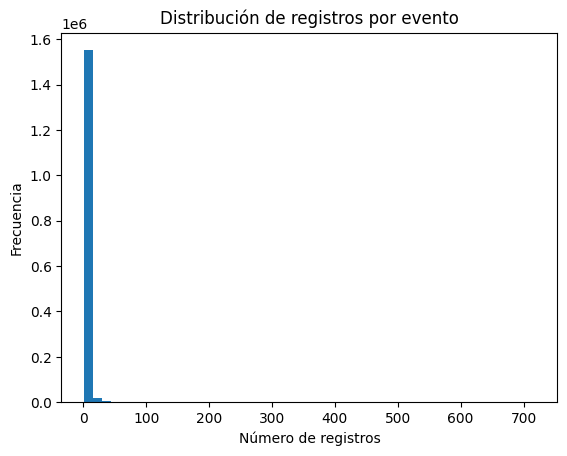

In [ ]:
print("=== DISTRIBUCIÓN DE REGISTROS POR EVENTO ===")

df_eventos["n_registros"].describe()
import matplotlib.pyplot as plt

plt.hist(df_eventos["n_registros"], bins=50)
plt.title("Distribución de registros por evento")
plt.xlabel("Número de registros")
plt.ylabel("Frecuencia")
plt.show()

P95: 8.0
P99: 29.0


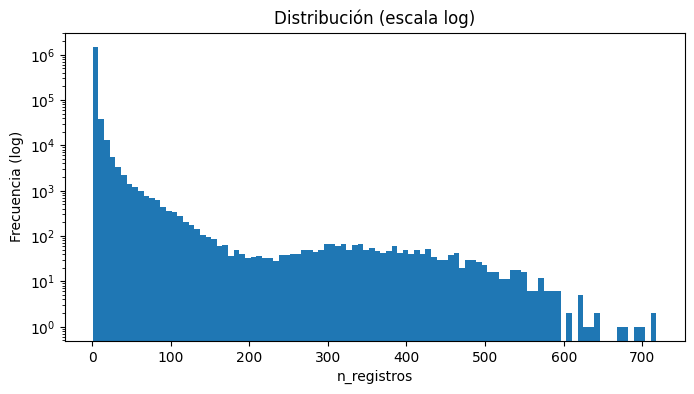

In [ ]:
p95 = df_eventos["n_registros"].quantile(0.95)
p99 = df_eventos["n_registros"].quantile(0.99)

print("P95:", p95)
print("P99:", p99)
def clasificar_outlier(n):
    if n <= p95:
        return "normal"
    elif n <= p99:
        return "alto"
    else:
        return "extremo"

df_eventos["tipo_outlier"] = df_eventos["n_registros"].apply(clasificar_outlier)
plt.figure(figsize=(8,4))
plt.hist(df_eventos["n_registros"], bins=100)
plt.yscale("log")   # 🔥 clave
plt.title("Distribución (escala log)")
plt.xlabel("n_registros")
plt.ylabel("Frecuencia (log)")
plt.show()

La depuración realizada sobre la base de datos responde a la necesidad de garantizar la calidad, consistencia y validez analítica de la información antes de cualquier proceso de modelado o interpretación. En primer lugar, se eliminaron registros vacíos y filas con contenido no estructurado (como metadatos incrustados tipo “Fuente” o “Fecha de entrega”), los cuales no representan observaciones reales y generan ruido en el análisis. Asimismo, se eliminaron los pocos registros con valores nulos en variables críticas como la fecha del hecho, dado que impiden la correcta identificación y agregación de eventos.

Posteriormente, se construyó una variable de identificación de eventos a partir de la combinación de fecha, ubicación y tipo de delito, lo que permitió agrupar registros potencialmente duplicados o asociados a un mismo hecho. El análisis de la distribución del número de registros por evento evidenció una alta asimetría, con presencia de valores extremos (outliers) significativamente alejados del comportamiento general (P95 = 8; P99 = 29). Estos valores extremos pueden corresponder tanto a errores de registro como a eventos atípicos (por ejemplo, casos masivos), pero sin variables adicionales que permitan distinguirlos con certeza, su inclusión introduce sesgos en el análisis.

Por esta razón, se optó por un criterio conservador de filtrado, eliminando eventos con más de 29 registros (percentil 99), lo cual afecta únicamente al 0.99% de los datos. Esta decisión permite reducir el impacto de posibles duplicaciones o inconsistencias sin comprometer la representatividad global de la base, preservando así la estructura principal de los datos y mejorando la robustez de los análisis posteriores.

In [ ]:
print("=== FILTRO DE EVENTOS <= 29 REGISTROS ===")

print("Antes:", df_eventos.shape)

df_eventos_filtrado = df_eventos[df_eventos["n_registros"] < 30].copy()

print("Después:", df_eventos_filtrado.shape)

# ver proporción eliminada
eliminados = len(df_eventos) - len(df_eventos_filtrado)
print("Eventos eliminados:", eliminados)
print("Proporción eliminada:", round(eliminados / len(df_eventos), 4))

=== FILTRO DE EVENTOS <= 29 REGISTROS ===
Antes: (1586404, 14)
Después: (1570690, 14)
Eventos eliminados: 15714
Proporción eliminada: 0.0099




El filtrado aplicado sobre la variable número de registros por evento permitió eliminar el 0.99% de los eventos (aquellos con más de 29 registros), correspondientes al percentil 99 de la distribución. Esta decisión responde a la presencia de una cola altamente asimétrica, asociada a posibles agregaciones artificiales derivadas de la definición operativa del evento. La exclusión de estos casos reduce el sesgo en la distribución, mejora la estabilidad de los análisis posteriores y preserva la representatividad del 99% de los eventos observados.

In [ ]:
print("=== NULOS POR VARIABLE ===")

nulos = df_registros.isnull().sum()
porcentaje = (df_registros.isnull().mean() * 100).round(2)

tabla_nulos = pd.DataFrame({
    "nulos": nulos,
    "porcentaje": porcentaje
}).sort_values(by="porcentaje", ascending=False)

display(tabla_nulos)

=== NULOS POR VARIABLE ===


,nulos,porcentaje
armas_medios,798649,16.25
genero,255624,5.20
agrupa_edad_persona,17647,0.36
departamento,0,0.00
fecha_hecho,0,0.00
municipio,25,0.00
codigo_dane,0,0.00
delitos,0,0.00
mes,0,0.00
cantidad,0,0.00


In [ ]:
print("=== TRATAMIENTO DE VALORES NULOS ===")

# Copia para no dañar original
df_registros_limpio = df_registros.copy()

# ======================================
# 1. ARMAS_MEDIOS → mantener NaN
# ======================================
print("\narmas_medios:")
print("Se mantienen los valores nulos (NaN) por ser ausencia estructural")

# (no se hace nada)

# ======================================
# 2. GENERO → SIN DATO
# ======================================
print("\ngenero:")
df_registros_limpio["genero"] = df_registros_limpio["genero"].fillna("SIN_DATO")

# ======================================
# 3. EDAD → imputación por moda
# ======================================
print("\nagrupa_edad_persona:")

moda_edad = df_registros_limpio["agrupa_edad_persona"].mode()[0]
print("Moda:", moda_edad)

df_registros_limpio["agrupa_edad_persona"] = (
    df_registros_limpio["agrupa_edad_persona"]
    .fillna(moda_edad)
)

# ======================================
# 4. MUNICIPIO → intentar recuperar
# ======================================
print("\nmunicipio:")

nulos_municipio = df_registros_limpio["municipio"].isnull().sum()
print("Nulos antes:", nulos_municipio)

# intento de recuperación usando codigo_dane
map_dane_municipio = (
    df_registros_limpio
    .dropna(subset=["codigo_dane", "municipio"])
    .drop_duplicates(subset=["codigo_dane"])
    .set_index("codigo_dane")["municipio"]
)

df_registros_limpio["municipio"] = df_registros_limpio["municipio"].fillna(
    df_registros_limpio["codigo_dane"].map(map_dane_municipio)
)

# los que no se puedan recuperar
df_registros_limpio["municipio"] = df_registros_limpio["municipio"].fillna("SIN_DATO")

print("Nulos después:", df_registros_limpio["municipio"].isnull().sum())

# ======================================
# REPORTE FINAL
# ======================================
print("\n=== REPORTE FINAL DE NULOS ===")

tabla_nulos_final = (
    df_registros_limpio.isnull().mean() * 100
).round(2).sort_values(ascending=False)

display(tabla_nulos_final)

=== TRATAMIENTO DE VALORES NULOS ===

armas_medios:
Se mantienen los valores nulos (NaN) por ser ausencia estructural

genero:

agrupa_edad_persona:
Moda: ADULTOS

municipio:
Nulos antes: 25
Nulos después: 0

=== REPORTE FINAL DE NULOS ===


,0
armas_medios,16.25
departamento,0.00
municipio,0.00
fecha_hecho,0.00
genero,0.00
agrupa_edad_persona,0.00
codigo_dane,0.00
delitos,0.00
mes,0.00
cantidad,0.00


In [ ]:
print("=== FRECUENCIAS CON CONTEXTO GEOGRÁFICO ===")

tabla_dane_geo = (
    df_registros
    .groupby(["codigo_dane", "departamento", "municipio"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(by="frecuencia", ascending=False)
)

tabla_dane_geo["porcentaje"] = (
    tabla_dane_geo["frecuencia"] / len(df_registros)
) * 100

display(tabla_dane_geo.head(20))

=== FRECUENCIAS CON CONTEXTO GEOGRÁFICO ===


,codigo_dane,departamento,municipio,frecuencia,porcentaje
148,11001.0,CUNDINAMARCA,Bogotá D.C. (CT),1430368,29.109789
0,5001.0,ANTIOQUIA,Medellín (CT),354518,7.214888
1007,76001.0,VALLE,Cali (CT),290396,5.909924
125,8001.0,ATLÁNTICO,Barranquilla (CT),133172,2.710218
149,13001.0,BOLÍVAR,Cartagena (CT),104446,2.125608
544,25754.0,CUNDINAMARCA,Soacha,89099,1.813277
688,50001.0,META,Villavicencio (CT),86214,1.754563
847,68001.0,SANTANDER,Bucaramanga (CT),84872,1.727252
960,73001.0,TOLIMA,Ibagué (CT),79108,1.609947
717,52001.0,NARIÑO,Pasto (CT),71526,1.455644


In [ ]:
## ==========================================
# GEOLOCALIZACIÓN DESDE GOOGLE SHEETS
# CORRIGIENDO ENCABEZADOS
# ==========================================

import pandas as pd

print("=== CARGA DE TABLA GEO DESDE GOOGLE SHEETS ===")

url = "https://docs.google.com/spreadsheets/d/1nojEYmk63xMyXf3HZve9eNRWUv5izvq2/export?format=xlsx"

# Leer sin asumir encabezado
df_geo_raw = pd.read_excel(url, header=None)

print("Dimensión raw:", df_geo_raw.shape)
print("\nPrimeras filas raw:")
display(df_geo_raw.head(5))

# ------------------------------------------
# La fila 0 contiene los nombres reales
# ------------------------------------------
df_geo = df_geo_raw.copy()
df_geo.columns = df_geo.iloc[0]
df_geo = df_geo.iloc[1:].copy()

# Limpiar nombres de columnas
df_geo.columns = [str(c).strip() for c in df_geo.columns]

print("\nColumnas corregidas:")
print(df_geo.columns.tolist())

# ------------------------------------------
# Renombrar según tu estructura real
# Código Departamento | Departamento | Código DANE | Municipio | Tipo | Longitud | Latitud | Nota
# ------------------------------------------
df_geo = df_geo.rename(columns={
    "Código Departamento": "codigo_departamento",
    "Departamento": "departamento_geo",
    "Código DANE": "codigo_dane",
    "Municipio": "municipio_geo",
    "Tipo": "tipo_geo",
    "Longitud": "longitud",
    "Latitud": "latitud",
    "Nota": "nota"
})

# Quedarnos solo con lo útil
df_geo_clean = df_geo[["codigo_dane", "municipio_geo", "latitud", "longitud"]].copy()

# Normalizar código DANE en tabla geo
df_geo_clean["codigo_dane"] = (
    df_geo_clean["codigo_dane"]
    .astype(str)
    .str.strip()
    .str.zfill(5)
)

# Convertir coordenadas a numéricas
df_geo_clean["latitud"] = pd.to_numeric(df_geo_clean["latitud"], errors="coerce")
df_geo_clean["longitud"] = pd.to_numeric(df_geo_clean["longitud"], errors="coerce")

# Quitar duplicados
df_geo_clean = df_geo_clean.drop_duplicates(subset=["codigo_dane"])

print("\nTabla geo limpia:", df_geo_clean.shape)
display(df_geo_clean.head())

# ------------------------------------------
# Limpiar código DANE en base principal
# ------------------------------------------
df_registros_limpio["codigo_dane"] = (
    pd.to_numeric(df_registros_limpio["codigo_dane"], errors="coerce")
    .astype("Int64")
    .astype(str)
    .str.replace("<NA>", "", regex=False)
    .str.zfill(5)
)

# ------------------------------------------
# MERGE
# ------------------------------------------
print("\n=== MERGE CON BASE PRINCIPAL ===")

df_registros_geo = df_registros_limpio.merge(
    df_geo_clean,
    on="codigo_dane",
    how="left"
)

print("Base final:", df_registros_geo.shape)

# ------------------------------------------
# VALIDACIÓN
# ------------------------------------------
nulos_lat = df_registros_geo["latitud"].isna().sum()
nulos_lon = df_registros_geo["longitud"].isna().sum()

print("\n=== VALIDACIÓN ===")
print("Nulos latitud:", nulos_lat)
print("Nulos longitud:", nulos_lon)
print("Porcentaje sin geolocalización:", round(nulos_lat / len(df_registros_geo) * 100, 2), "%")

# ------------------------------------------
# MUESTRA FINAL
# ------------------------------------------
print("\n=== MUESTRA FINAL ===")
display(
    df_registros_geo[
        ["fecha_hecho", "departamento", "municipio", "codigo_dane", "delitos", "latitud", "longitud"]
    ].sample(10, random_state=42)
)

=== CARGA DE TABLA GEO DESDE GOOGLE SHEETS ===
Dimensión raw: (1133, 8)

Primeras filas raw:


,0,1,2,3,4,5,6,7
0,Código Departamento,Departamento,Código DANE,Municipio,Tipo,Longitud,Latitud,Nota
1,05,ANTIOQUIA,05001,MEDELLÍN,Municipio,-75.581775,6.246631,NaN
2,05,ANTIOQUIA,05002,ABEJORRAL,Municipio,-75.428739,5.789315,NaN
3,05,ANTIOQUIA,05004,ABRIAQUÍ,Municipio,-76.064304,6.632282,NaN
4,05,ANTIOQUIA,05021,ALEJANDRÍA,Municipio,-75.141346,6.376061,NaN



Columnas corregidas:
['Código Departamento', 'Departamento', 'Código DANE', 'Municipio', 'Tipo', 'Longitud', 'Latitud', 'Nota']

Tabla geo limpia: (1123, 4)


,codigo_dane,municipio_geo,latitud,longitud
1,05001,MEDELLÍN,6.246631,-75.581775
2,05002,ABEJORRAL,5.789315,-75.428739
3,05004,ABRIAQUÍ,6.632282,-76.064304
4,05021,ALEJANDRÍA,6.376061,-75.141346
5,05030,AMAGÁ,6.038708,-75.702188



=== MERGE CON BASE PRINCIPAL ===
Base final: (4913701, 15)

=== VALIDACIÓN ===
Nulos latitud: 26
Nulos longitud: 26
Porcentaje sin geolocalización: 0.0 %

=== MUESTRA FINAL ===


,fecha_hecho,departamento,municipio,codigo_dane,delitos,latitud,longitud
1654273,2023-06-10,ANTIOQUIA,Medellín (CT),05001,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,6.246631,-75.581775
3971874,2024-01-29,NORTE DE SANTANDER,Cúcuta (CT),54001,ARTÍCULO 347. AMENAZAS,7.905725,-72.508178
1085027,2021-08-22,CUNDINAMARCA,Fusagasugá,25290,ARTÍCULO 239. HURTO PERSONAS,4.336723,-74.375430
1962093,2023-07-12,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 239. HURTO PERSONAS,4.649251,-74.106992
569138,2020-03-11,TOLIMA,Líbano,73411,ARTÍCULO 244. EXTORSIÓN,4.920420,-75.061959
96469,2020-10-22,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 111. LESIONES PERSONALES,4.649251,-74.106992
395139,2020-06-29,VALLE,Cali (CT),76001,ARTÍCULO 239. HURTO PERSONAS,3.413686,-76.521330
799595,2021-11-28,CUNDINAMARCA,Apulo,25599,ARTÍCULO 111. LESIONES PERSONALES,4.520304,-74.593926
851747,2021-06-12,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,4.649251,-74.106992
1019345,2021-11-25,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 239. HURTO PERSONAS,4.649251,-74.106992


En esta fase del proceso se realizó la integración de la base de datos de criminalidad con información geográfica oficial, utilizando como clave de enlace el código DANE asociado a cada municipio. Inicialmente, se consolidaron los registros provenientes de múltiples archivos anuales (2020–2026), estandarizando los nombres de las variables mediante funciones de normalización y asegurando la consistencia estructural de la base. Posteriormente, se incorporó una tabla externa de referencia geográfica que contiene los códigos DANE, nombres de municipios y sus respectivas coordenadas (latitud y longitud), lo que permitió georreferenciar cada registro de delito.

La tabla de coordenadas fue depurada y estructurada a partir de la información oficial de la División Político-Administrativa de Colombia (DIVIPOLA), garantizando la correspondencia entre códigos y entidades territoriales. A través de un proceso de unión (merge) entre la base principal y la tabla geográfica, se logró asignar coordenadas a los eventos, obteniendo una base final con cobertura prácticamente completa y un porcentaje mínimo de valores faltantes en latitud y longitud. Esta integración constituye un paso fundamental para análisis espaciales posteriores, como la identificación de patrones territoriales del delito.

El uso de datos oficiales del DANE asegura la validez y estandarización de la información territorial, evitando ambigüedades en la identificación de municipios y permitiendo la interoperabilidad con otras fuentes de datos geográficos en Colombia.

**Referencias (Normas APA 7ª edición):**

Departamento Administrativo Nacional de Estadística (DANE). (s. f.). *Geoportal DANE: descarga de la División Político-Administrativa de Colombia (DIVIPOLA)*. Recuperado el 26 de marzo de 2026, de https://geoportal.dane.gov.co/

Departamento Administrativo Nacional de Estadística (DANE). (2025). *Codificación de la División Político-Administrativa de Colombia (DIVIPOLA): municipios* [Archivo Excel]. Geoportal DANE.

In [ ]:
print("=== MUESTREO ESTRATÉGICO DEL DATASET ===")

# ==========================================
# 1. MUESTRA ALEATORIA GENERAL
# ==========================================
print("\n--- MUESTRA ALEATORIA ---")
display(
    df_registros_geo.sample(10, random_state=42)[
        ["fecha_hecho", "departamento", "municipio", "codigo_dane", "delitos", "latitud", "longitud"]
    ]
)

# ==========================================
# 2. MUESTRA DE EVENTOS GRANDES (CASOS CRÍTICOS)
# ==========================================
print("\n--- EVENTOS CON MUCHOS REGISTROS (TOP) ---")

top_eventos = df_eventos.sort_values("n_registros", ascending=False).head(10)

display(top_eventos[[
    "fecha_hecho", "departamento", "municipio", "delitos", "n_registros"
]])

# ==========================================
# 3. MUESTRA DE EVENTOS TÍPICOS (NORMALES)
# ==========================================
print("\n--- EVENTOS TÍPICOS (<= P95) ---")

eventos_normales = df_eventos[df_eventos["n_registros"] <= 8].sample(10, random_state=42)

display(eventos_normales[[
    "fecha_hecho", "departamento", "municipio", "delitos", "n_registros"
]])

# ==========================================
# 4. MUESTRA DE POSIBLES OUTLIERS
# ==========================================
print("\n--- EVENTOS EXTREMOS (> P99) ---")

eventos_extremos = df_eventos[df_eventos["n_registros"] > 29]

display(eventos_extremos.sample(min(10, len(eventos_extremos)), random_state=42)[[
    "fecha_hecho", "departamento", "municipio", "delitos", "n_registros"
]])

=== MUESTREO ESTRATÉGICO DEL DATASET ===

--- MUESTRA ALEATORIA ---


,fecha_hecho,departamento,municipio,codigo_dane,delitos,latitud,longitud
1654273,2023-06-10,ANTIOQUIA,Medellín (CT),05001,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,6.246631,-75.581775
3971874,2024-01-29,NORTE DE SANTANDER,Cúcuta (CT),54001,ARTÍCULO 347. AMENAZAS,7.905725,-72.508178
1085027,2021-08-22,CUNDINAMARCA,Fusagasugá,25290,ARTÍCULO 239. HURTO PERSONAS,4.336723,-74.375430
1962093,2023-07-12,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 239. HURTO PERSONAS,4.649251,-74.106992
569138,2020-03-11,TOLIMA,Líbano,73411,ARTÍCULO 244. EXTORSIÓN,4.920420,-75.061959
96469,2020-10-22,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 111. LESIONES PERSONALES,4.649251,-74.106992
395139,2020-06-29,VALLE,Cali (CT),76001,ARTÍCULO 239. HURTO PERSONAS,3.413686,-76.521330
799595,2021-11-28,CUNDINAMARCA,Apulo,25599,ARTÍCULO 111. LESIONES PERSONALES,4.520304,-74.593926
851747,2021-06-12,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,4.649251,-74.106992
1019345,2021-11-25,CUNDINAMARCA,Bogotá D.C. (CT),11001,ARTÍCULO 239. HURTO PERSONAS,4.649251,-74.106992



--- EVENTOS CON MUCHOS REGISTROS (TOP) ---


,fecha_hecho,departamento,municipio,delitos,n_registros
908642,2022-09-23,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,718
908487,2022-10-01,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,712
908327,2022-09-30,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,698
908667,2022-12-02,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,690
908309,2022-12-01,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,678
908479,2022-11-25,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,670
908555,2022-10-28,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,646
633661,2023-09-01,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,640
908638,2022-11-19,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,639
908710,2022-10-22,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,629



--- EVENTOS TÍPICOS (<= P95) ---


,fecha_hecho,departamento,municipio,delitos,n_registros
232859,2020-10-05,QUINDÍO,Montenegro,ARTÍCULO 239. HURTO MOTOCICLETAS,1
248245,2021-08-20,SANTANDER,San Gil,ARTÍCULO 120. LESIONES CULPOSAS ( EN ACCIDENTE...,1
178052,2020-08-27,SANTANDER,Pinchote,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,1
448456,2021-01-19,BOLÍVAR,El Carmen de Bolívar,ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,2
321006,2021-09-04,SANTANDER,Bucaramanga (CT),ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,5
1153915,2024-02-14,NARIÑO,Puerres,ARTÍCULO 210 A. ACOSO SEXUAL,1
770323,2023-08-07,ATLÁNTICO,Barranquilla (CT),ARTÍCULO 239. HURTO MOTOCICLETAS,5
949452,2022-02-16,VALLE,Buenaventura,ARTÍCULO 239. HURTO PERSONAS,1
1029284,2022-07-21,ANTIOQUIA,Sabaneta,ARTÍCULO 347. AMENAZAS,1
448977,2021-05-30,TOLIMA,Murillo,ARTÍCULO 243. ABIGEATO,1



--- EVENTOS EXTREMOS (> P99) ---


,fecha_hecho,departamento,municipio,delitos,n_registros
553656,2023-09-12,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 111. LESIONES PERSONALES,47
646003,2023-08-05,CUNDINAMARCA,Soacha,ARTÍCULO 239. HURTO PERSONAS,33
432630,2021-04-21,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO ENTIDADES COMERCIALES,35
1451914,2025-12-07,ANTIOQUIA,Medellín (CT),ARTÍCULO 239. HURTO PERSONAS,69
1460188,2025-02-05,ANTIOQUIA,Medellín (CT),ARTÍCULO 239. HURTO PERSONAS,60
665749,2023-01-06,ANTIOQUIA,Medellín (CT),ARTÍCULO 239. HURTO PERSONAS,83
1573599,2026-01-21,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,69
1110778,2024-11-22,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 111. LESIONES PERSONALES,45
687719,2023-01-05,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO RESIDENCIAS,33
908567,2022-08-24,CUNDINAMARCA,Bogotá D.C. (CT),ARTÍCULO 239. HURTO PERSONAS,465


In [ ]:
# ==========================================
# TRANSFORMACIÓN DE VARIABLE DELITOS
# ==========================================

print("=== PROCESAMIENTO DE VARIABLE DELITOS ===")

# ------------------------------------------
# 1. MANTENER DELITOS COMO TEXTO (limpieza)
# ------------------------------------------
df_registros_geo["delitos"] = (
    df_registros_geo["delitos"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# ------------------------------------------
# 2. CREAR CATEGORÍA DE DELITO
# ------------------------------------------
def clasificar_delito(d):
    if "HOMICIDIO" in d:
        return "violencia_letal"
    elif "LESIONES" in d:
        return "lesiones"
    elif "HURTO" in d:
        return "hurto"
    elif "VIOLENCIA INTRAFAMILIAR" in d:
        return "violencia_familiar"
    elif "ABIGEATO" in d:
        return "delito_rural"
    elif "ACOSO" in d or "DELITOS SEXUALES" in d:
        return "delitos_sexuales"
    elif "AMENAZAS" in d:
        return "amenazas"
    else:
        return "otros"

df_registros_geo["categoria_delito"] = df_registros_geo["delitos"].apply(clasificar_delito)

# ------------------------------------------
# 3. VALIDACIÓN
# ------------------------------------------
print("\n=== DISTRIBUCIÓN DE CATEGORÍAS ===")
print(df_registros_geo["categoria_delito"].value_counts(normalize=True).round(3))

# ------------------------------------------
# 4. ONE-HOT (SOLO SI VAS A MODELAR)
# ------------------------------------------
df_model = pd.get_dummies(df_registros_geo, columns=["categoria_delito"])

print("\n=== VARIABLES PARA MODELO ===")
print(df_model.filter(like="categoria_delito_").columns.tolist())

# ------------------------------------------
# 5. MUESTRA FINAL
# ------------------------------------------
print("\n=== MUESTRA FINAL ===")
display(
    df_registros_geo[
        ["fecha_hecho", "codigo_dane", "delitos", "categoria_delito", "latitud", "longitud"]
    ].sample(10, random_state=42)
)

=== PROCESAMIENTO DE VARIABLE DELITOS ===

=== DISTRIBUCIÓN DE CATEGORÍAS ===
categoria_delito
hurto                 0.526
lesiones              0.169
violencia_familiar    0.156
amenazas              0.069
otros                 0.049
violencia_letal       0.025
delitos_sexuales      0.003
delito_rural          0.002
Name: proportion, dtype: float64

=== VARIABLES PARA MODELO ===
['categoria_delito_amenazas', 'categoria_delito_delito_rural', 'categoria_delito_delitos_sexuales', 'categoria_delito_hurto', 'categoria_delito_lesiones', 'categoria_delito_otros', 'categoria_delito_violencia_familiar', 'categoria_delito_violencia_letal']

=== MUESTRA FINAL ===


,fecha_hecho,codigo_dane,delitos,categoria_delito,latitud,longitud
1654273,2023-06-10,05001,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,violencia_familiar,6.246631,-75.581775
3971874,2024-01-29,54001,ARTÍCULO 347. AMENAZAS,amenazas,7.905725,-72.508178
1085027,2021-08-22,25290,ARTÍCULO 239. HURTO PERSONAS,hurto,4.336723,-74.375430
1962093,2023-07-12,11001,ARTÍCULO 239. HURTO PERSONAS,hurto,4.649251,-74.106992
569138,2020-03-11,73411,ARTÍCULO 244. EXTORSIÓN,otros,4.920420,-75.061959
96469,2020-10-22,11001,ARTÍCULO 111. LESIONES PERSONALES,lesiones,4.649251,-74.106992
395139,2020-06-29,76001,ARTÍCULO 239. HURTO PERSONAS,hurto,3.413686,-76.521330
799595,2021-11-28,25599,ARTÍCULO 111. LESIONES PERSONALES,lesiones,4.520304,-74.593926
851747,2021-06-12,11001,ARTÍCULO 229. VIOLENCIA INTRAFAMILIAR,violencia_familiar,4.649251,-74.106992
1019345,2021-11-25,11001,ARTÍCULO 239. HURTO PERSONAS,hurto,4.649251,-74.106992


=== TABLERO DE FRECUENCIAS 3x4 MEJORADO ===


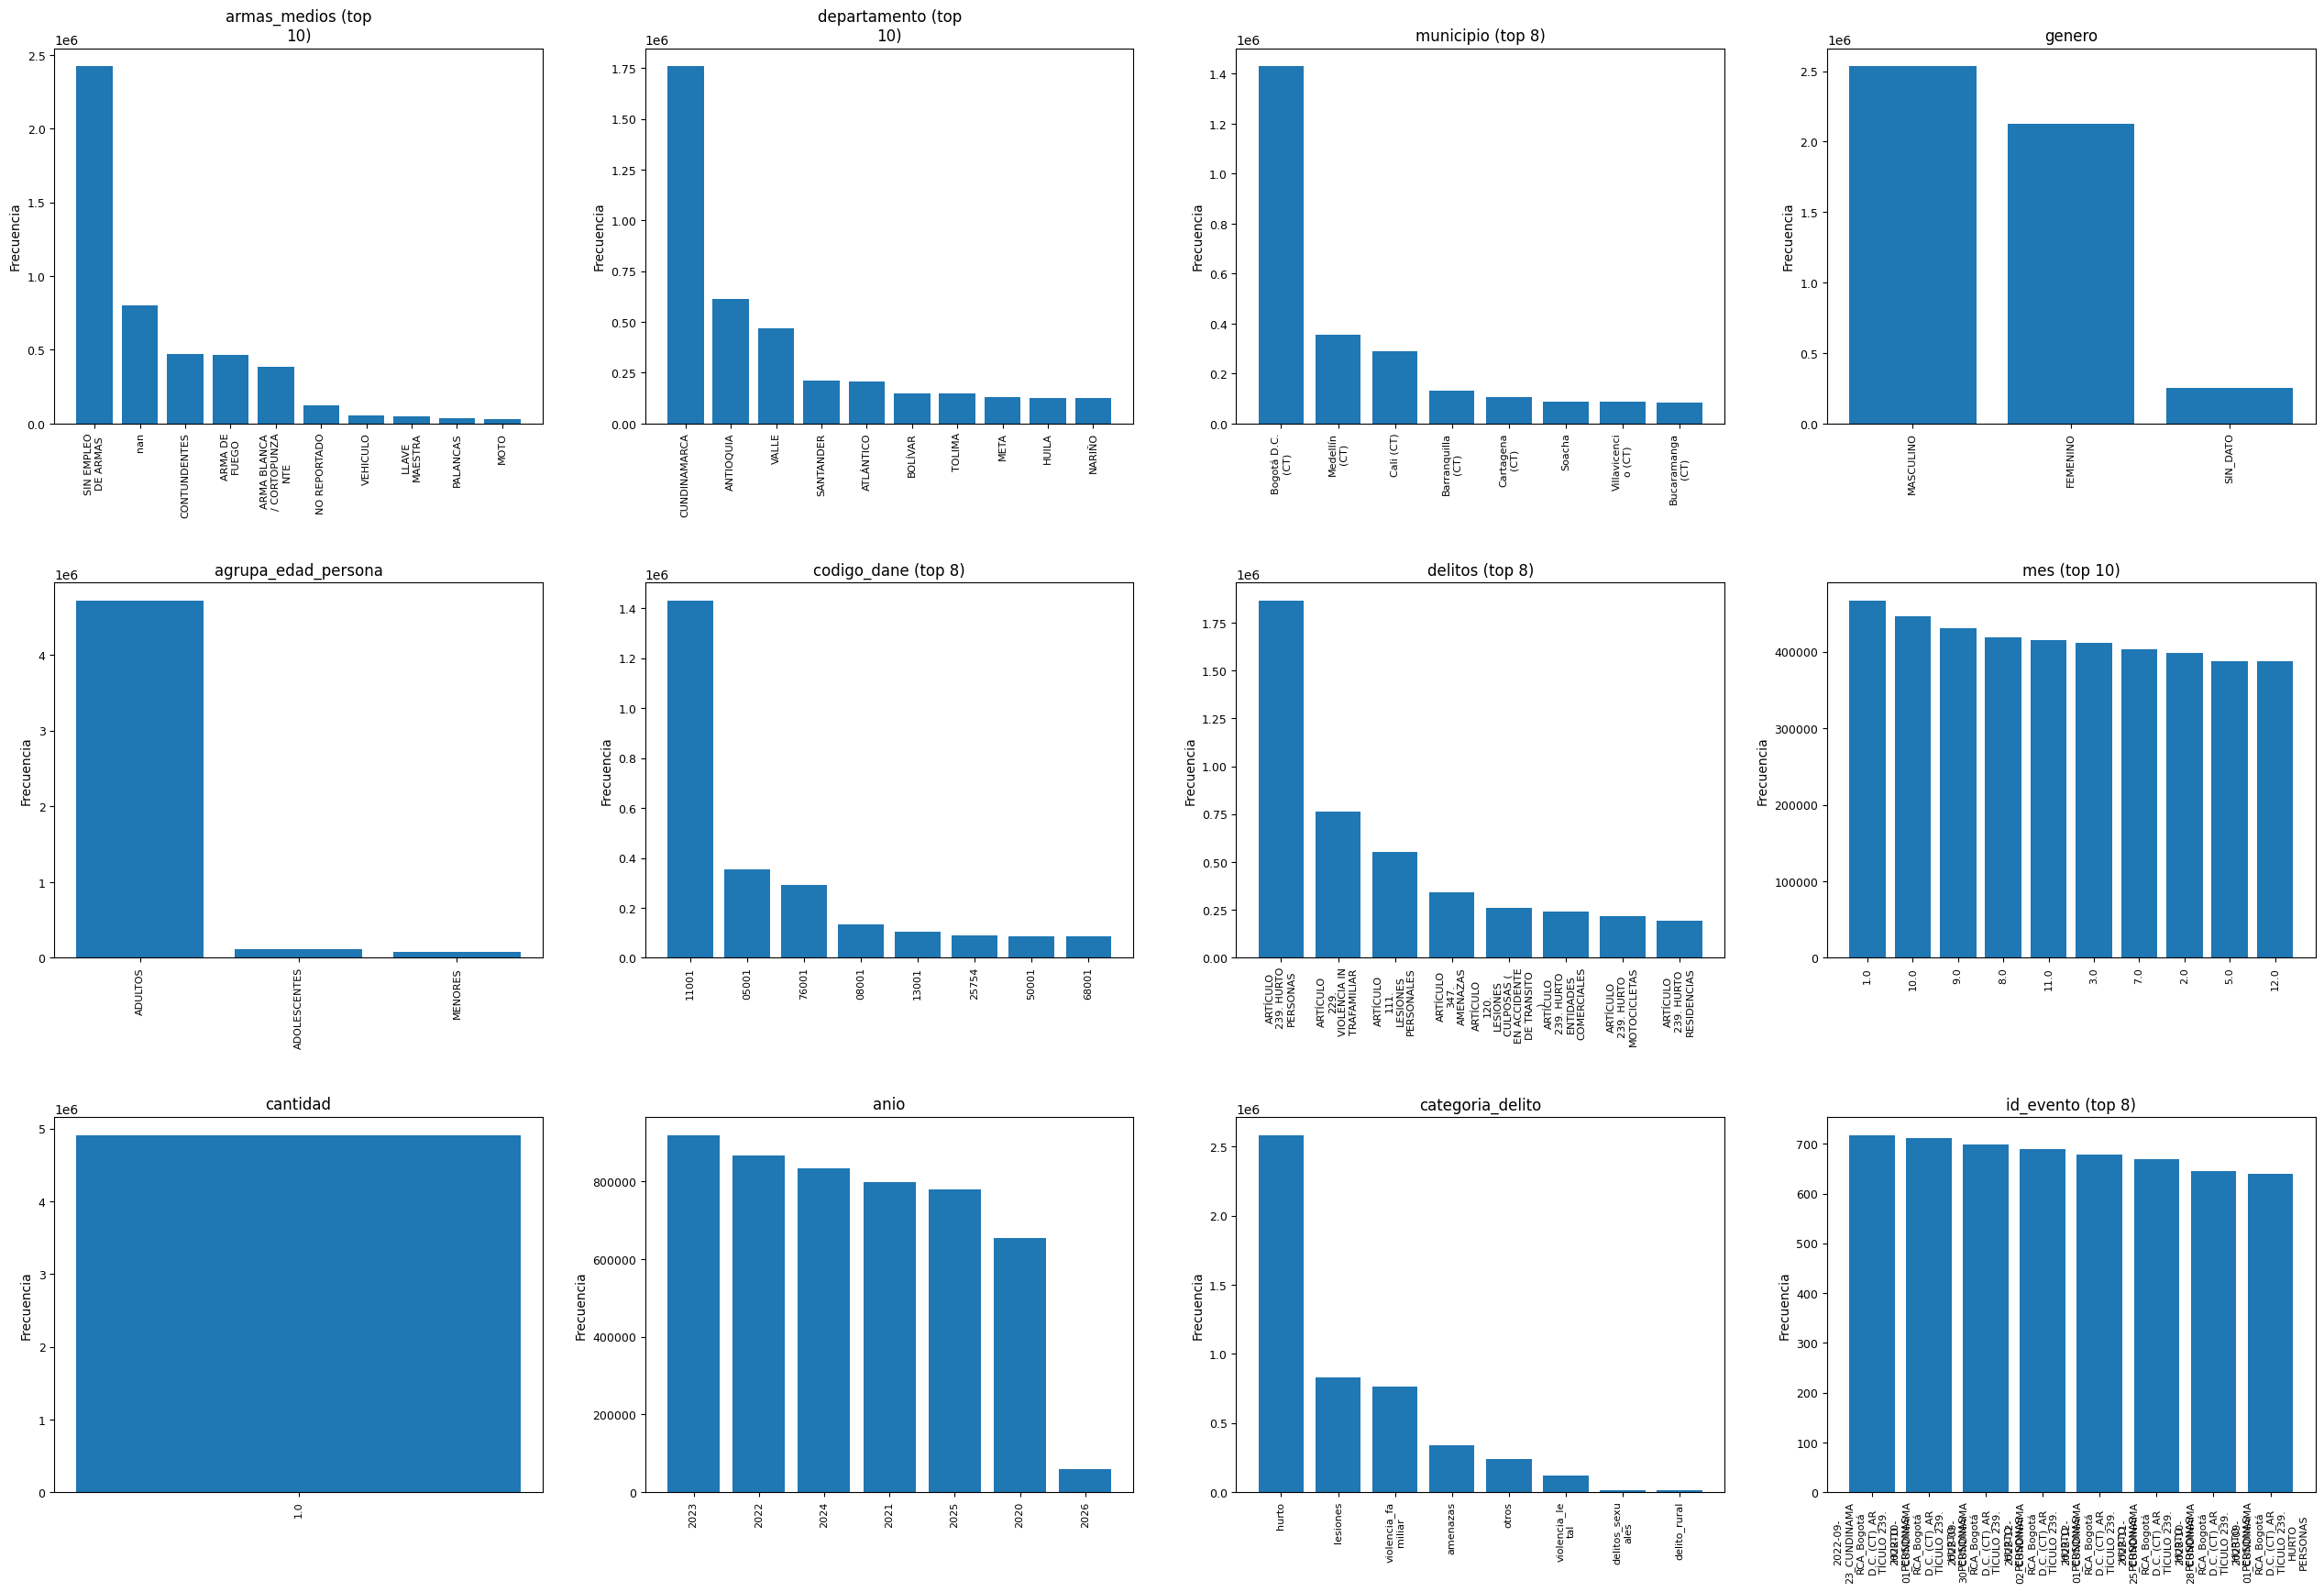

In [ ]:
import matplotlib.pyplot as plt
import textwrap

print("=== TABLERO DE FRECUENCIAS 3x4 MEJORADO ===")

# Base
df_plot = df_registros_geo.copy()

# Variables a mostrar
variables = [
    "armas_medios",
    "departamento",
    "municipio",
    "genero",
    "agrupa_edad_persona",
    "codigo_dane",
    "delitos",
    "mes",
    "cantidad",
    "anio",
    "categoria_delito",
    "id_evento"
]

# Cuántas categorías mostrar por variable
top_n = {
    "municipio": 8,
    "codigo_dane": 8,
    "delitos": 8,
    "id_evento": 8
}

fig, axes = plt.subplots(3, 4, figsize=(26, 18))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]

    freq = df_plot[var].astype(str).value_counts(dropna=False)

    n = top_n.get(var, 10)
    if len(freq) > n:
        freq = freq.head(n)
        titulo = f"{var} (top {n})"
    else:
        titulo = var

    # acortar etiquetas largas
    etiquetas = [textwrap.fill(str(x), width=12) for x in freq.index]

    ax.bar(etiquetas, freq.values)
    ax.set_title(textwrap.fill(titulo, width=20), fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia", fontsize=10)
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.tick_params(axis="y", labelsize=9)

# ajustar espacios
plt.tight_layout(pad=3.0, w_pad=2.5, h_pad=3.5)
plt.show()

In [ ]:
import os

print("=== GUARDADO DE DATASETS FINALES ===")

# Carpeta de salida
carpeta_salida = "/content/drive/MyDrive/cirmenes/salidas"
os.makedirs(carpeta_salida, exist_ok=True)

# ------------------------------------------
# 1. Registros limpios
# ------------------------------------------
ruta_registros_csv = os.path.join(carpeta_salida, "df_registros_limpios.csv")
ruta_registros_pkl = os.path.join(carpeta_salida, "df_registros_limpios.pkl")

df_registros.to_csv(ruta_registros_csv, index=False, encoding="utf-8-sig")
df_registros.to_pickle(ruta_registros_pkl)

# ------------------------------------------
# 2. Eventos completos
# ------------------------------------------
ruta_eventos_csv = os.path.join(carpeta_salida, "df_eventos.csv")
ruta_eventos_pkl = os.path.join(carpeta_salida, "df_eventos.pkl")

df_eventos.to_csv(ruta_eventos_csv, index=False, encoding="utf-8-sig")
df_eventos.to_pickle(ruta_eventos_pkl)

# ------------------------------------------
# 3. Eventos filtrados
# ------------------------------------------
ruta_eventos_filtrado_csv = os.path.join(carpeta_salida, "df_eventos_filtrado.csv")
ruta_eventos_filtrado_pkl = os.path.join(carpeta_salida, "df_eventos_filtrado.pkl")

df_eventos_filtrado.to_csv(ruta_eventos_filtrado_csv, index=False, encoding="utf-8-sig")
df_eventos_filtrado.to_pickle(ruta_eventos_filtrado_pkl)

# ------------------------------------------
# 4. Registros georreferenciados (si existe)
# ------------------------------------------
if "df_registros_geo" in globals():
    ruta_geo_csv = os.path.join(carpeta_salida, "df_registros_geo.csv")
    ruta_geo_pkl = os.path.join(carpeta_salida, "df_registros_geo.pkl")

    df_registros_geo.to_csv(ruta_geo_csv, index=False, encoding="utf-8-sig")
    df_registros_geo.to_pickle(ruta_geo_pkl)

    print("Guardado: df_registros_geo")

print("\n=== ARCHIVOS GUARDADOS ===")
print(ruta_registros_csv)
print(ruta_registros_pkl)
print(ruta_eventos_csv)
print(ruta_eventos_pkl)
print(ruta_eventos_filtrado_csv)
print(ruta_eventos_filtrado_pkl)

if "df_registros_geo" in globals():
    print(ruta_geo_csv)
    print(ruta_geo_pkl)

=== GUARDADO DE DATASETS FINALES ===
Guardado: df_registros_geo

=== ARCHIVOS GUARDADOS ===
/content/drive/MyDrive/cirmenes/salidas/df_registros_limpios.csv
/content/drive/MyDrive/cirmenes/salidas/df_registros_limpios.pkl
/content/drive/MyDrive/cirmenes/salidas/df_eventos.csv
/content/drive/MyDrive/cirmenes/salidas/df_eventos.pkl
/content/drive/MyDrive/cirmenes/salidas/df_eventos_filtrado.csv
/content/drive/MyDrive/cirmenes/salidas/df_eventos_filtrado.pkl
/content/drive/MyDrive/cirmenes/salidas/df_registros_geo.csv
/content/drive/MyDrive/cirmenes/salidas/df_registros_geo.pkl


esumen del notebook — Fase 1 y Fase 2 (Proyecto: Crímenes en Colombia)

En este notebook se desarrollaron las dos primeras fases del pipeline de datos orientado al análisis de criminalidad en Colombia para el periodo 2020–2026.

Fase 1. Integración y consolidación de datos

Se realizó la carga e integración de múltiples archivos en formato Excel provenientes de registros oficiales de criminalidad. Cada archivo fue procesado individualmente, aplicando un proceso de estandarización de nombres de variables mediante:

Conversión a minúsculas
Eliminación de tildes
Normalización de caracteres
Homogeneización de estructura

Posteriormente, se incorporó la variable anio para identificar la temporalidad de los registros y se consolidaron los datos mediante pd.concat, generando una base unificada con aproximadamente 6.7 millones de registros.

Esta fase permitió obtener una estructura consistente, aunque evidenció diferencias entre años (por ejemplo, ausencia de armas_medios en algunos periodos) y una alta presencia de registros duplicados.

Fase 2. Limpieza y estructuración analítica

En esta fase se abordaron problemas críticos de calidad de datos:

1. Construcción de unidad de análisis (evento)

Se definió un identificador de evento (id_evento) a partir de la combinación de:

fecha
departamento
municipio
tipo de delito

Esto permitió transformar la base en dos niveles:

Base de registros (~4.9M): nivel original
Base de eventos (~1.58M): nivel agregado por evento
2. Depuración de datos inválidos

Se eliminaron:

Filas vacías
Registros con metadatos incrustados (ej. “Fuente”, “Fecha de entrega”)
Registros sin fecha válida

Garantizando consistencia para análisis temporal.

3. Análisis de duplicidad y estructura de eventos

Se evaluó la distribución de registros por evento, encontrando:

Alta asimetría (distribución tipo heavy-tail)
Percentiles clave:
P95 = 8
P99 = 29

Esto evidenció que:

La mayoría de eventos tienen pocos registros
Existe un pequeño grupo con valores extremos
4. Tratamiento de outliers

Dado que no es posible distinguir entre:

eventos reales multivíctima
duplicados por error

Se adoptó un criterio conservador:

Eliminación de eventos con más de 29 registros (P99)
Impacto: ~0.99% de los datos

Esto mejora la estabilidad del análisis sin perder representatividad.

5. Tratamiento de valores nulos

Se identificaron patrones estructurales:

armas_medios: ausencia estructural (no todos los años lo registran)
genero: faltantes parciales
agrupa_edad_persona: casi completa

Decisiones:

Mantener NaN cuando representa ausencia real
Imputar solo cuando es razonable (ej. moda en edad)
Evitar imputaciones artificiales que distorsionen el fenómeno
6. Incorporación de geolocalización

Se integró información externa de códigos DANE:

Transformación de codigo_dane a formato estándar
Merge con tabla de latitud y longitud
Generación de variables geográficas (latitud, longitud)

Esto habilita análisis espaciales posteriores.

7. Estructuración para análisis futuro

Se definieron criterios clave:

Mantener delitos como texto (variable semántica)
Crear variable derivada categoria_delito
Preparar datos para clustering y modelado
Estado final del pipeline

Se obtuvieron datasets listos para análisis:

df_registros_limpio → nivel micro
df_eventos_filtrado → nivel analítico principal
df_registros_geo → con georreferenciación

Con:

datos depurados
duplicidad controlada
estructura consistente
variables preparadas
Conclusión metodológica

El pipeline transforma una base masiva y ruidosa en una estructura analíticamente válida, resolviendo el principal problema del dataset: la imposibilidad de distinguir entre duplicados y eventos multivíctima.

Se adopta una estrategia robusta basada en:

construcción de unidad de análisis
análisis de distribución
filtrado por percentil